# ML Regression from Scratch - Notebook 2: Polynomial Regression (Single Feature)

**Goal:** extend the simple linear model from Notebook 1 to **polynomial
regression** on the same feature (`TotalHours` → `CapstoneScore`), compare
degrees 1, 2 and 3, and study **overfitting vs underfitting** - all built
from scratch with NumPy, no scikit-learn.

We will:
1. Reload the data and recap why feature scaling matters (from Notebook 1)
2. Implement `create_polynomial_features` and `fit_polynomial`
3. Fit degree-1, degree-2 and degree-3 models
4. Compare their fitted curves and their train/test metrics
5. Discuss where overfitting starts to show up

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. Load & prepare the data

Same setup as Notebook 1: filter to the `'Foundations of ML'` course, use
`TotalHours` as the single feature and `CapstoneScore` as the target.

In [4]:
df = pd.read_csv('student scores.csv')
df = df[df['CourseName'] == 'Foundations of ML'].reset_index(drop=True)

X = df['TotalHours'].values.astype(float)
Y = df['CapstoneScore'].values.astype(float)

print(f"Rows: {len(df)}")
print(f"X (TotalHours) -> min: {X.min():.1f}, max: {X.max():.1f}")

Rows: 72
X (TotalHours) -> min: 10.5, max: 98.8


In [5]:
def train_test_split_scratch(X, Y, test_size=0.2, seed=42):
    """Shuffle-and-slice train/test split, no ML libraries involved."""
    m = len(Y)
    rng = np.random.RandomState(seed)
    shuffled_idx = rng.permutation(m)
    n_test = int(m * test_size)
    test_idx = shuffled_idx[:n_test]
    train_idx = shuffled_idx[n_test:]
    return X[train_idx], X[test_idx], Y[train_idx], Y[test_idx]


X_train, X_test, Y_train, Y_test = train_test_split_scratch(X, Y, test_size=0.2, seed=42)
print(f"Train size: {len(Y_train)},  Test size: {len(Y_test)}")

Train size: 58,  Test size: 14


## 2. Why we need feature scaling here more than ever

Notebook 1 showed that gradient descent on raw `TotalHours` (≈10-99) is
already ill-conditioned for plain linear regression. Polynomial features
make this **much worse**: with total hours around 56, $x^2\approx 3{,}100$
and $x^3\approx 175{,}000$ - three wildly different scales in the same
design matrix. Without standardizing every column, gradient descent would
need a different learning rate per power just to avoid diverging.

So the pipeline for this notebook is:

$$x \;\longrightarrow\; [x^1, x^2, \dots, x^d] \;\longrightarrow\; \text{standardize each column} \;\longrightarrow\; \text{add bias column} \;\longrightarrow\; \text{gradient descent}$$

## 3. `create_polynomial_features`

Turns a 1-D feature into a matrix of powers $[x^1, x^2, \dots, x^{degree}]$
(the bias/intercept column is added later, *after* scaling - you should
never standardize a constant column of 1s, since its std is 0).

In [6]:
def create_polynomial_features(X, degree):
    """
    Build polynomial power features (NOT including the bias column).

    X      : 1-D numpy array of length m, the raw feature
    degree : highest power to include

    Returns an (m, degree) matrix whose j-th column is X ** (j+1),
    i.e. columns = [x, x^2, ..., x^degree]
    """
    m = len(X)
    X_poly = np.zeros((m, degree))
    for d in range(1, degree + 1):
        X_poly[:, d - 1] = X ** d
    return X_poly


# Quick check with degree 3 on the first 3 training points
create_polynomial_features(X_train[:3], degree=3)

array([[9.73000000e+01, 9.46729000e+03, 9.21167317e+05],
       [2.66000000e+01, 7.07560000e+02, 1.88210960e+04],
       [9.03000000e+01, 8.15409000e+03, 7.36314327e+05]])

## 4. Standardizing & the full training pipeline

`standardize_features` computes mean/std **from the training set only**
(to avoid leaking test-set information) and applies the same transform to
any other set passed in. `fit_polynomial` chains everything together:
raw feature → polynomial powers → standardize → add bias → gradient
descent, exactly like the required signature `fit_polynomial(X, y, degree,
learning_rate)`.

In [7]:
def standardize_features(X_poly, mu=None, sigma=None):
    """
    Z-score standardize each column of X_poly.
    If mu/sigma are not given they are computed from X_poly itself
    (use this on the training set); if they ARE given, X_poly is scaled
    using those (already-fitted) statistics (use this on the test set).
    """
    if mu is None or sigma is None:
        mu = X_poly.mean(axis=0)
        sigma = X_poly.std(axis=0)
    X_scaled = (X_poly - mu) / sigma
    return X_scaled, mu, sigma


def add_bias(X):
    """Prepend a column of ones for the intercept term."""
    return np.column_stack([np.ones(len(X)), X])


def compute_cost(X_design, y, theta):
    """Same MSE cost as Notebook 1, in matrix/vector form."""
    m = len(y)
    y_hat = X_design.dot(theta)
    return (1 / (2 * m)) * np.sum((y_hat - y) ** 2)


def compute_gradients(X_design, y, theta):
    """Vectorised gradient: (1/m) * X^T (y_hat - y)"""
    m = len(y)
    y_hat = X_design.dot(theta)
    return (1 / m) * X_design.T.dot(y_hat - y)


def fit_polynomial(X, y, degree, learning_rate, n_iterations=3000):
    """
    Full training pipeline for degree-`degree` polynomial regression.

    X, y          : 1-D arrays, raw (unscaled) feature and target
    degree        : polynomial degree to fit
    learning_rate : alpha for gradient descent
    n_iterations  : max number of gradient descent steps

    Returns:
        theta        : learned parameters, theta[0] is the bias
        cost_history : list of cost values recorded each iteration
        mu, sigma    : the polynomial-feature scaling stats (needed to
                       transform new data the same way at prediction time)
    """
    X_poly = create_polynomial_features(X, degree)
    X_scaled, mu, sigma = standardize_features(X_poly)
    X_design = add_bias(X_scaled)

    m, n = X_design.shape
    theta = np.zeros(n)
    cost_history = []

    for i in range(n_iterations):
        cost = compute_cost(X_design, y, theta)
        if not np.isfinite(cost):
            break
        cost_history.append(cost)
        theta = theta - learning_rate * compute_gradients(X_design, y, theta)

    return theta, cost_history, mu, sigma


def predict_polynomial(X, theta, degree, mu, sigma):
    """Predict on raw (unscaled) X using an already-fitted theta/mu/sigma."""
    X_poly = create_polynomial_features(X, degree)
    X_scaled, _, _ = standardize_features(X_poly, mu, sigma)
    X_design = add_bias(X_scaled)
    return X_design.dot(theta)

## 5. Evaluation metrics (same four as Notebook 1)

In [8]:
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def evaluate(y_true, y_pred):
    return {
        'MSE':  mean_squared_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'MAE':  mean_absolute_error(y_true, y_pred),
        'R2':   r2_score(y_true, y_pred),
    }

## 6. Fit degrees 1, 2 and 3

Same learning rate and iteration budget for all three - that's only fair
to compare, and it's possible because every polynomial column is
standardized first.

In [9]:
degrees = [1, 2, 3]
LEARNING_RATE = 0.1
N_ITERATIONS = 3000

poly_results = {}

for degree in degrees:
    theta, cost_history, mu, sigma = fit_polynomial(
        X_train, Y_train, degree=degree, learning_rate=LEARNING_RATE, n_iterations=N_ITERATIONS
    )

    y_pred_train = predict_polynomial(X_train, theta, degree, mu, sigma)
    y_pred_test = predict_polynomial(X_test, theta, degree, mu, sigma)

    poly_results[degree] = {
        'theta': theta,
        'cost_history': cost_history,
        'mu': mu,
        'sigma': sigma,
        'train_metrics': evaluate(Y_train, y_pred_train),
        'test_metrics': evaluate(Y_test, y_pred_test),
    }

    print(f"degree={degree} | iterations run={len(cost_history):<5} | "
          f"final cost={cost_history[-1]:.4f} | "
          f"train R2={poly_results[degree]['train_metrics']['R2']:.4f} | "
          f"test R2={poly_results[degree]['test_metrics']['R2']:.4f}")

degree=1 | iterations run=3000  | final cost=11.8857 | train R2=0.9257 | test R2=0.7302
degree=2 | iterations run=3000  | final cost=11.8212 | train R2=0.9261 | test R2=0.7436
degree=3 | iterations run=3000  | final cost=11.8306 | train R2=0.9260 | test R2=0.7443


### 6.1 Convergence check

All three degrees should converge smoothly now that every input column is
standardized - a direct payoff of the scaling step.

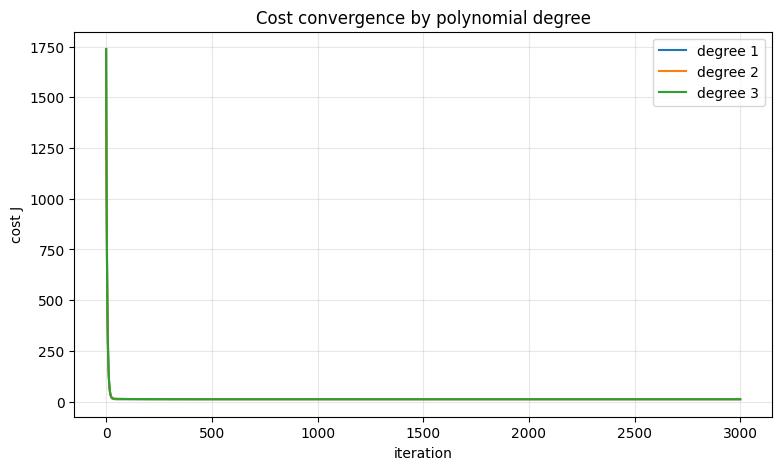

In [10]:
plt.figure(figsize=(9, 5))
for degree in degrees:
    plt.plot(poly_results[degree]['cost_history'], label=f"degree {degree}")
plt.xlabel("iteration")
plt.ylabel("cost J")
plt.title("Cost convergence by polynomial degree")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Visualizing the fitted curves

Plot all three fitted curves over the same scatter of actual data to see
how the shape changes as degree increases.

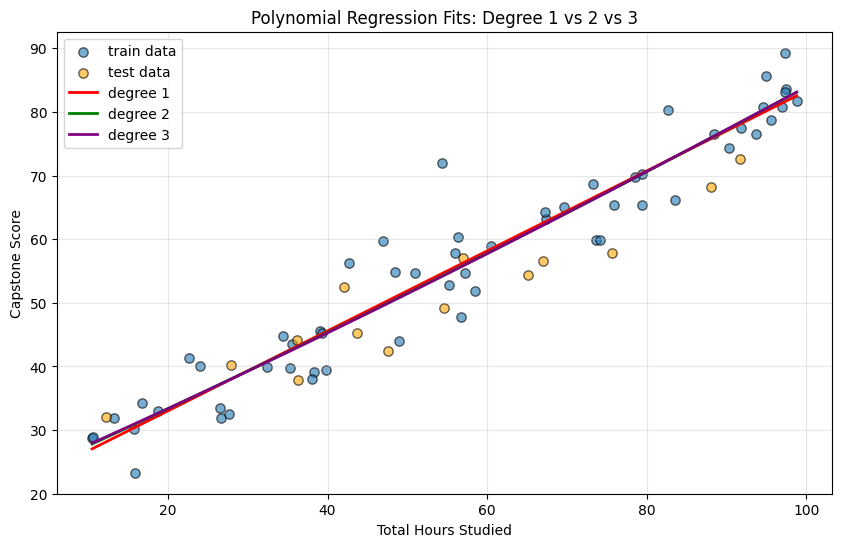

In [11]:
x_line = np.linspace(X.min(), X.max(), 200)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, Y_train, s=45, alpha=0.6, edgecolor='k', label='train data')
plt.scatter(X_test, Y_test, s=45, alpha=0.6, edgecolor='k', color='orange', label='test data')

colors = {1: 'red', 2: 'green', 3: 'purple'}
for degree in degrees:
    r = poly_results[degree]
    y_line = predict_polynomial(x_line, r['theta'], degree, r['mu'], r['sigma'])
    plt.plot(x_line, y_line, color=colors[degree], linewidth=2, label=f"degree {degree}")

plt.xlabel('Total Hours Studied')
plt.ylabel('Capstone Score')
plt.title('Polynomial Regression Fits: Degree 1 vs 2 vs 3')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Overfitting vs underfitting analysis

Comparing train and test metrics side by side, per degree, is the
standard way to spot overfitting: if train error keeps dropping while test
error stalls or rises, the extra flexibility is fitting noise rather than
signal.

In [12]:
rows = []
for degree in degrees:
    tr = poly_results[degree]['train_metrics']
    te = poly_results[degree]['test_metrics']
    rows.append({
        'degree': degree,
        'train_MSE': round(tr['MSE'], 3), 'test_MSE': round(te['MSE'], 3),
        'train_R2':  round(tr['R2'], 4),  'test_R2':  round(te['R2'], 4),
        'train_RMSE': round(tr['RMSE'], 3), 'test_RMSE': round(te['RMSE'], 3),
        'gap (test_MSE - train_MSE)': round(te['MSE'] - tr['MSE'], 3),
    })

poly_summary_df = pd.DataFrame(rows)
poly_summary_df

,degree,train_MSE,test_MSE,train_R2,test_R2,train_RMSE,test_RMSE,gap (test_MSE - train_MSE)
0,1,23.771,32.548,0.9257,0.7302,4.876,5.705,8.776
1,2,23.642,30.929,0.9261,0.7436,4.862,5.561,7.287
2,3,23.661,30.851,0.9260,0.7443,4.864,5.554,7.190


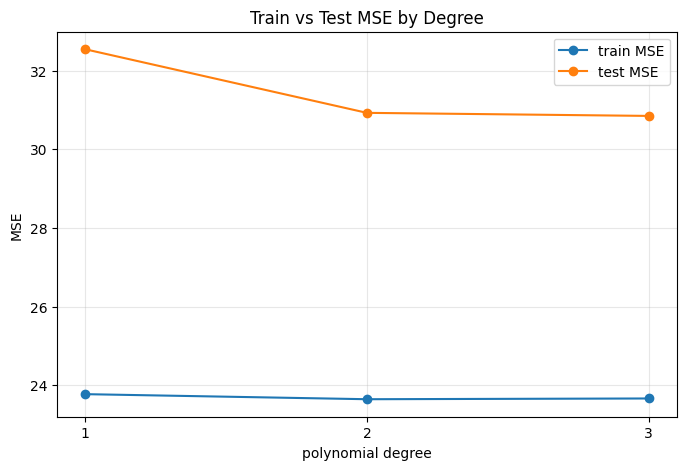

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(poly_summary_df['degree'], poly_summary_df['train_MSE'], 'o-', label='train MSE')
ax.plot(poly_summary_df['degree'], poly_summary_df['test_MSE'], 'o-', label='test MSE')
ax.set_xlabel('polynomial degree')
ax.set_ylabel('MSE')
ax.set_xticks(degrees)
ax.set_title('Train vs Test MSE by Degree')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

### Reading the overfitting/underfitting pattern

- **Degree 1** (a straight line) is the most constrained model - it can
  only capture a linear trend. If both train and test error are
  relatively high and close to each other, the model is likely
  **underfitting**: it is too simple to capture whatever curvature exists
  in the relationship.
- **Degree 2/3** add curvature, so training error should drop as the
  degree increases - the curve can bend to hug the training points more
  closely. Watch what happens to the *test* error at the same time:
  - If test error drops (or stays flat) alongside train error, the extra
    flexibility is capturing real signal - a genuine improvement.
  - If test error stops improving or gets *worse* while train error keeps
    falling, that gap (`test_MSE - train_MSE` in the table) is the
    signature of **overfitting**: the curve is bending to fit noise in the
    58-row training set rather than the underlying trend.
- With only ~70 total data points for a single feature, degree 3 has the
  most room to overfit - three curve-shaping parameters plus the
  intercept is a lot of flexibility for this little data. The
  degree-vs-MSE plot above is the direct evidence for which regime we're
  in on this particular train/test split.

## 9. Takeaways

- `create_polynomial_features` + `standardize_features` + `add_bias` is a
  reusable three-step pipeline - the same pattern we'll reuse for the
  full multi-feature dataset in Notebook 3/4.
- Standardizing every polynomial column (not just the raw feature) is
  what makes a *single* learning rate work cleanly across degree 1, 2 and
  3 in this notebook - without it, higher powers would dominate the
  gradient and diverge, just like the unscaled case in Notebook 1.
- Higher polynomial degree is not automatically better: the real judge is
  **test-set performance**, not training-set fit. That comparison is the
  whole point of the train/test split.